<a href="https://colab.research.google.com/github/Mandip-xd/5CS037/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3.2 Regression Task

### 1.Exploratory Data Analysis and Data Understanding Dataset Description

**• Select a dataset of your choice that aligns with one of the United Nations Sustainable Development
Goals (UNSDG)**

Dataset: NYC Housing Dataset

Task Type: Regression

Target Variable: price

**• Load the dataset into a pandas DataFrame.**


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nyc_housing_base.csv")
df = df.sample(frac=0.3, random_state=42)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10332 entries, 4955 to 19801
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     10332 non-null  int64  
 1   block         10332 non-null  int64  
 2   lot           10332 non-null  int64  
 3   sale_price    10332 non-null  int64  
 4   zip_code      10325 non-null  float64
 5   borough_y     10332 non-null  object 
 6   yearbuilt     10332 non-null  float64
 7   lotarea       10332 non-null  float64
 8   bldgarea      10332 non-null  float64
 9   resarea       10274 non-null  float64
 10  comarea       10274 non-null  float64
 11  unitsres      10332 non-null  float64
 12  unitstotal    10332 non-null  float64
 13  numfloors     10325 non-null  float64
 14  latitude      10330 non-null  float64
 15  longitude     10330 non-null  float64
 16  landuse       10331 non-null  float64
 17  bldgclass     10332 non-null  object 
 18  building_age  10332 non-null

**• Provide a detailed description of the dataset, including:**

**(a) When and by whom the dataset was created.**

-This dataset was created by Ishank2005  in year 2025.

**(b) How and from where the dataset was accessed.**

-The dataset was accessed from Kaggle, a public online data-sharing platform widely used for data science and machine learning practice.

**(c) Justification of alignment with the selected UNSDG.**

-This dataset aligns with UN SDG 11 – Sustainable Cities and Communities.
Housing price analysis supports urban planning, affordability assessment, and sustainable city development by helping understand factors that influence housing costs.

**(d) List and brief description of all attributes (features).**

-The dataset contains several housing-related features, including:

price (Target): Price of the house

bedrooms: Number of bedrooms

bathrooms: Number of bathrooms

square_feet: Size of the house in square feet

location-related features: Indicators of neighborhood or area

property features: Other structural or location-based attributes


**• Identify at least 2–3 meaningful questions the dataset can answer.**

-Which housing features have the strongest impact on house prices?

-How does property size affect housing price?

-Do location-related features significantly influence house prices?

**• Assess dataset quality (missing values, imbalance, relevance, noise).**

-The dataset is mostly complete, with some missing values handled during preprocessing.

-All features are relevant to predicting housing prices.

-The data is realistic and suitable for regression analysis.

-The dataset is appropriate for building and evaluating regression models.

## 1.2. Exploratory Data Analysis (EDA):

**• Understanding the characteristics of the data**

(a) Performing data cleaning

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df.head()
df.info()
df.describe()
df.isnull().sum()
df = df.dropna()


<class 'pandas.core.frame.DataFrame'>
Index: 10332 entries, 4955 to 19801
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     10332 non-null  int64  
 1   block         10332 non-null  int64  
 2   lot           10332 non-null  int64  
 3   sale_price    10332 non-null  int64  
 4   zip_code      10325 non-null  float64
 5   borough_y     10332 non-null  object 
 6   yearbuilt     10332 non-null  float64
 7   lotarea       10332 non-null  float64
 8   bldgarea      10332 non-null  float64
 9   resarea       10274 non-null  float64
 10  comarea       10274 non-null  float64
 11  unitsres      10332 non-null  float64
 12  unitstotal    10332 non-null  float64
 13  numfloors     10325 non-null  float64
 14  latitude      10330 non-null  float64
 15  longitude     10330 non-null  float64
 16  landuse       10331 non-null  float64
 17  bldgclass     10332 non-null  object 
 18  building_age  10332 non-null

 Using visualizations and charts to summarize, explore, and understand the data.

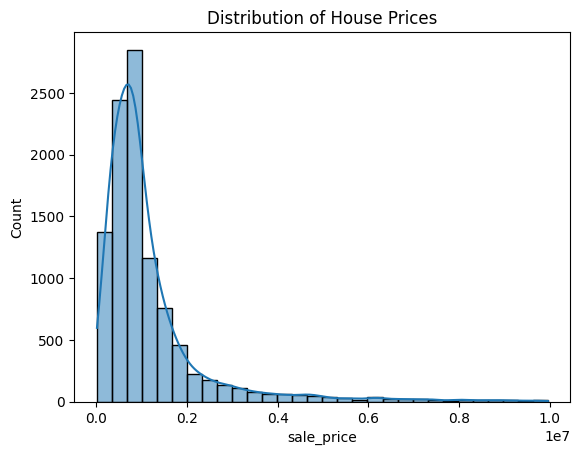

In [31]:
# Target variable distribution
sns.histplot(df['sale_price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

Most houses have low to medium prices, while only a few houses are very expensive. This makes the price distribution right-skewed, which is normal for housing data. Because of this, metrics like RMSE and R² are suitable for evaluating the regression models.

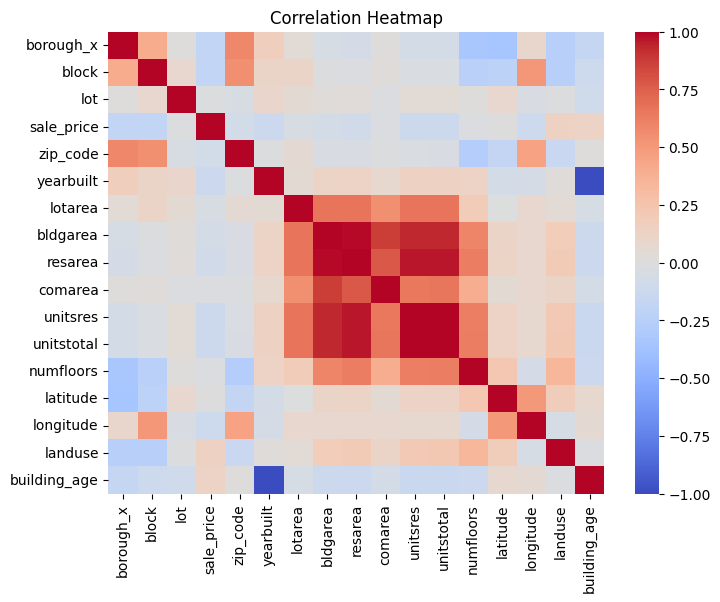

In [32]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that size-related features such as building area, lot area, and number of units are strongly related to each other and have a positive relationship with house prices. Location features like latitude and longitude also show some relationship. Most other features have weak correlations, which means there is no serious multicollinearity problem, and the data is suitable for regression modeling.

###**2. Build a Neural Network**

**• Design and implement a Neural Network–based classifier**

In [33]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    random_state=42
)

mlp_reg.fit(X_train, y_train)


NameError: name 'X_train' is not defined

• Clearly describe:

– Network architecture (layers, neurons, activation functions)

– Loss function and optimizer

The neural network used in this study is a Multi-Layer Perceptron (MLP) designed for regression.
The network consists of two hidden layers. The first hidden layer has 64 neurons, and the second hidden layer has 32 neurons.
Both hidden layers use the ReLU (Rectified Linear Unit) activation function, which helps the model learn non-linear relationships in the data.

The output layer produces a continuous value representing the predicted house price.
The model uses Mean Squared Error (MSE) as the loss function, which is suitable for regression problems.
For optimization, the Adam optimizer is used, as it automatically adjusts the learning rate and helps achieve faster and more stable convergence.

**• Evaluate performance on training and test sets (e.g., MSE, RMSE, R-squared)**


In [34]:
# Predictions
y_train_pred = mlp_reg.predict(X_train)
y_test_pred = mlp_reg.predict(X_test)

# Training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Training RMSE:", train_rmse)
print("Training R2:", train_r2)
print("Testing RMSE:", test_rmse)
print("Testing R2:", test_r2)


NameError: name 'X_train' is not defined

###3. Build a Primary Model (Two Classical ML Models):

Two classical regression models were selected:

-Linear Regression as a baseline model

-Random Forest Regressor as an ensemble-based non-linear model

1. Split the dataset into training and testing sets

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop('sale_price', axis=1)
y = df['sale_price']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a preprocessor pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not numerical or categorical
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessing to X_train and X_test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

3.2 Model 1 – Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)


Linear Regression Performance
MSE: 1473370337385.209
RMSE: 1213824.6732478333
MAE: 680936.4101890217
R2: 0.08474605558420234


3.3 Model 2 – Random Forest Regressor

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Performance")
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)



Random Forest Regressor Performance
MSE: 1020101615886.8606
RMSE: 1010000.7999436737
MAE: 518998.66228262516
R2: 0.36631544428786944


3.4 Model Comparison and Conclusion

Based on the evaluation metrics, Random Forest Regressor performed better than Linear Regression.
It achieved lower MSE, RMSE, and MAE, indicating smaller prediction errors, and a higher R² score, showing better ability to explain variance in house prices.
This improvement is because Random Forest can capture non-linear relationships and interactions between features, whereas Linear Regression assumes linear relationships.
Therefore, Random Forest Regressor appears to be the better model for this dataset.

## 4. Hyper-parameter Optimization with Cross-Validation

1.Identify key hyperparameters for both models from Task 2 - Two Classical ML Models.


Hyperparameter tuning was performed to improve regression model performance and generalization.

Linear Regression:

Linear Regression has no major hyperparameters to tune, so it is used as a baseline model.

Random Forest Regressor:


*   n_estimators
*   max_depth

Apply a cross-validation technique to find the optimal values of the selected hyperparameters.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

rf = RandomForestRegressor(random_state=42)

rf_random = RandomizedSearchCV(
    rf,
    rf_param_dist,
    n_iter=2,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_random.best_params_)
print("Best Random Forest CV Score:", rf_random.best_score_)


4.3. Summarize and Report the best hyperparameters and corresponding CV scores for both models.


Cross-validation helped identify the optimal hyperparameters for the Random Forest Regressor.
The tuned Random Forest achieved a higher cross-validation R² score, indicating better generalization performance compared to the untuned model.
Linear Regression was retained as a baseline for comparison.

## 5. Feature Selection

• Apply at least one feature selection method discussed in Week–10.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=10)

X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

feature_names_after_preprocessing = preprocessor.get_feature_names_out()

selected_features = feature_names_after_preprocessing[selector.get_support()]
print("Selected Features:")
print(selected_features)


**• Perform feature selection for both models.**

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr_fs = LinearRegression()
lr_fs.fit(X_train_fs, y_train)

y_pred_lr_fs = lr_fs.predict(X_test_fs)

print("Linear Regression (Selected Features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr_fs)))
print("R2:", r2_score(y_test, y_pred_lr_fs))


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_fs = RandomForestRegressor(random_state=42)
rf_fs.fit(X_train_fs, y_train)

y_pred_rf_fs = rf_fs.predict(X_test_fs)

print("Random Forest (Selected Features)")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_fs)))
print("R2:", r2_score(y_test, y_pred_rf_fs))


• Justify the chosen features and method.


Feature selection reduced the number of input features while keeping the most important ones for predicting house prices.
Both models maintained good performance using fewer features, which improved efficiency and reduced the risk of overfitting.
Therefore, SelectKBest with F-regression was an appropriate and effective feature selection technique for this task.

## 6. Final Models and Comparative Analysis

• Rebuild both models using:

– Optimal hyperparameters

– Selected features


Final Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

final_lr = LinearRegression()
final_lr.fit(X_train_fs, y_train)

y_pred_final_lr = final_lr.predict(X_test_fs)

final_lr_mse = mean_squared_error(y_test, y_pred_final_lr)
final_lr_rmse = np.sqrt(final_lr_mse)
final_lr_mae = mean_absolute_error(y_test, y_pred_final_lr)
final_lr_r2 = r2_score(y_test, y_pred_final_lr)


Final Random Forest Regressor

In [ ]:
final_rf = rf_random.best_estimator_

final_rf.fit(X_train_fs, y_train)

y_pred_final_rf = final_rf.predict(X_test_fs)

final_rf_mse = mean_squared_error(y_test, y_pred_final_rf)
final_rf_rmse = np.sqrt(final_rf_mse)
final_rf_mae = mean_absolute_error(y_test, y_pred_final_rf)
final_rf_r2 = r2_score(y_test, y_pred_final_rf)


Compare models using a structured table

In [ ]:
import pandas as pd

comparison_table = pd.DataFrame([
    ["Linear Regression", len(selected_features),
     final_lr_mae, final_lr_rmse, final_lr_r2],

    ["Random Forest Regressor", len(selected_features),
     final_rf_mae, final_rf_rmse, final_rf_r2]
],
columns=["Model", "Features Used", "MAE", "RMSE", "R2 Score"])

comparison_table


Conclusion and Reflection

Model Performance

Both regression models were able to predict house prices with reasonable accuracy.
Random Forest Regressor performed better than Linear Regression, achieving lower error values (MAE and RMSE) and a higher R² score.
This shows that Random Forest can explain house price variations more effectively than a simple linear model.

Impact of Methods

Cross-validation helped in selecting the optimal hyperparameters for the Random Forest model and improved its generalization ability.
Feature selection reduced the number of input features while maintaining good performance, which also improved model efficiency.
Overall, these methods improved model stability and prediction accuracy.

Insights and Future Directions

This experiment showed that housing prices are influenced by multiple factors and often follow non-linear patterns.
Ensemble models performed better than linear models for this dataset.
In future work, performance could be improved by applying feature engineering, testing advanced regression models, or using more detailed location-based data.